In [5]:
import firebase_admin
from firebase_admin import credentials, firestore, storage

cred = credentials.Certificate("fhtw-soe-firebase-adminsdk-fbsvc-5a77ac938f.json")

firebase_admin.initialize_app(cred, {
    "storageBucket": "soe-music-recommender.appspot.com"
})

db = firestore.client()
bucket = storage.bucket()

tree D:\Documents\00-Personal\01-FHTW\SS2026\MAD-BB-2-SS2026-SOE-Py\soe-spotify\data\raw\SpotGenTrack /f
nTrack /f                                                                                                                                                                     Folder PATH listing for volume Volume
Volume serial number is AE39-6A16
D:\DOCUMENTS\00-PERSONAL\01-FHTW\SS2026\MAD-BB-2-SS2026-SOE-PY\SOE-SPOTIFY\DATA\RAW\SPOTGENTRACK
├───Data Sources
│       spotify_albums.csv
│       spotify_artists.csv
│       spotify_tracks.csv
│
└───Features Extracted
        low_level_audio_features.csv
        lyrics_features.csv

In [31]:
import os
import pyspark
import seaborn as sns
import pandas as pd
import pyarrow
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark import SparkConf
from pyspark.sql.types import *
from pyspark.sql.functions import collect_list, col, concat_ws, substring
from pyspark.sql.functions import col, split, monotonically_increasing_id
from pyspark.ml.feature import CountVectorizer
from pyspark.sql import DataFrame
from pyarrow import flight
from datetime import datetime
# from sklearn.feature_selection import mutual_info_regression
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

In [14]:
## Data Source

albums = pd.read_csv(r'D:\Documents\00-Personal\01-FHTW\SS2026\MAD-BB-2-SS2026-SOE-Py\soe-spotify\data\raw\SpotGenTrack\Data Sources\spotify_albums.csv')
artists = pd.read_csv(r'D:\Documents\00-Personal\01-FHTW\SS2026\MAD-BB-2-SS2026-SOE-Py\soe-spotify\data\raw\SpotGenTrack\Data Sources\spotify_artists.csv')
tracks = pd.read_csv(r'D:\Documents\00-Personal\01-FHTW\SS2026\MAD-BB-2-SS2026-SOE-Py\soe-spotify\data\raw\SpotGenTrack\Data Sources\spotify_tracks.csv')

## Features

audio = pd.read_csv(r'D:\Documents\00-Personal\01-FHTW\SS2026\MAD-BB-2-SS2026-SOE-Py\soe-spotify\data\raw\SpotGenTrack\Features Extracted\low_level_audio_features.csv')
lyrics = pd.read_csv(r'D:\Documents\00-Personal\01-FHTW\SS2026\MAD-BB-2-SS2026-SOE-Py\soe-spotify\data\raw\SpotGenTrack\Features Extracted\lyrics_features.csv')


In [32]:
print("Albums:")
print(albums.columns.values)

print("\nArtists:")
print(artists.columns.values)

print("\nTracks:")
print(tracks.columns.values)

print("\nAudio Features:")
print(audio.columns.values)

print("\nLyrics Features:")
print(lyrics.columns.values)

Albums:
<ArrowStringArray>
[            'Unnamed: 0',             'album_type',              'artist_id',      'available_markets',          'external_urls',
                   'href',                     'id',                 'images',                   'name',           'release_date',
 'release_date_precision',           'total_tracks',               'track_id',        'track_name_prev',                    'uri',
                   'type']
Length: 16, dtype: str

Artists:
<ArrowStringArray>
['Unnamed: 0', 'artist_popularity', 'followers', 'genres', 'id', 'name', 'track_id', 'track_name_prev', 'type']
Length: 9, dtype: str

Tracks:
<ArrowStringArray>
[       'Unnamed: 0',      'acousticness',          'album_id',      'analysis_url',        'artists_id', 'available_markets',
           'country',      'danceability',       'disc_number',       'duration_ms',            'energy',              'href',
                'id',  'instrumentalness',               'key',          'liveness', 

In [33]:
pd.isnull(tracks).sum()

Unnamed: 0           0
acousticness         0
album_id             0
analysis_url         0
artists_id           0
available_markets    0
country              0
danceability         0
disc_number          0
duration_ms          0
energy               0
href                 0
id                   0
instrumentalness     0
key                  0
liveness             0
loudness             0
lyrics               0
mode                 0
name                 0
playlist             0
popularity           0
preview_url          0
speechiness          0
tempo                0
time_signature       0
track_href           0
track_name_prev      0
track_number         0
uri                  0
valence              0
type                 0
dtype: int64

In [27]:
tracks.info()

<class 'pandas.DataFrame'>
RangeIndex: 101939 entries, 0 to 101938
Data columns (total 32 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         101939 non-null  int64  
 1   acousticness       101939 non-null  float64
 2   album_id           101939 non-null  str    
 3   analysis_url       101939 non-null  str    
 4   artists_id         101939 non-null  str    
 5   available_markets  101939 non-null  str    
 6   country            101939 non-null  str    
 7   danceability       101939 non-null  float64
 8   disc_number        101939 non-null  float64
 9   duration_ms        101939 non-null  float64
 10  energy             101939 non-null  float64
 11  href               101939 non-null  str    
 12  id                 101939 non-null  str    
 13  instrumentalness   101939 non-null  float64
 14  key                101939 non-null  float64
 15  liveness           101939 non-null  float64
 16  loudness     

In [28]:
tracks.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,101939.0,50969.000000,29427.398883,0.0,25484.5000,50969.000000,76453.5000,101938.000
acousticness,101939.0,0.352124,0.334855,0.0,0.0407,0.238000,0.6450,0.996
danceability,101939.0,0.586015,0.177724,0.0,0.4800,0.610000,0.7140,0.989
disc_number,101939.0,1.032166,0.566789,1.0,1.0000,1.000000,1.0000,81.000
duration_ms,101939.0,246770.803304,190430.295141,1155.0,184000.0000,216893.000000,261055.0000,5505831.000
energy,101939.0,0.586479,0.260170,0.0,0.4110,0.629000,0.7980,1.000
instrumentalness,101939.0,0.148776,0.304024,0.0,0.0000,0.000037,0.0344,1.000
key,101939.0,5.270858,3.577679,0.0,2.0000,5.000000,8.0000,11.000
liveness,101939.0,0.197640,0.175391,0.0,0.0956,0.124000,0.2410,0.999
loudness,101939.0,-9.462720,6.198508,-60.0,-11.1490,-7.599000,-5.5090,2.719


In [30]:
from yellowbrick.target import FeatureCorrelation

feature_names = ['acousticness', 'danceability', 'energy', 'instrumentalness',
       'liveness', 'loudness', 'speechiness', 'tempo', 'valence','duration_ms','explicit','key','mode','year']

X, y = data[feature_names], data['popularity']

# Create a list of the feature names
features = np.array(feature_names)

# Instantiate the visualizer
visualizer = FeatureCorrelation(labels=features)

plt.rcParams['figure.figsize']=(20,20)
visualizer.fit(X, y)     # Fit the data to the visualizer
visualizer.show()



NameError: name 'data' is not defined

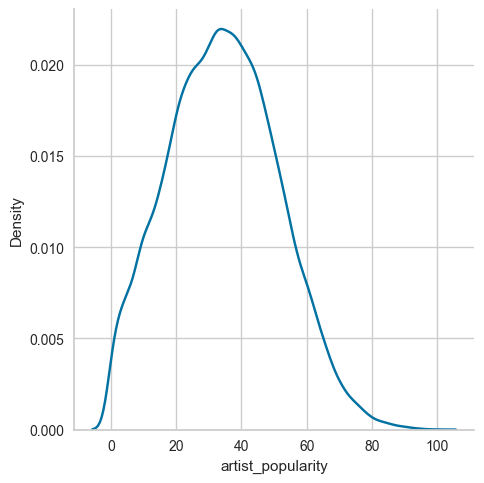

In [34]:
sns.displot(data=artists, x='artist_popularity', kind='kde')

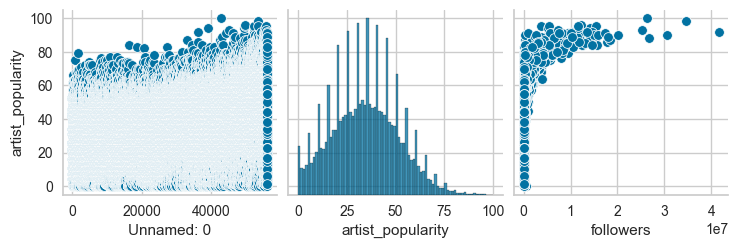

In [35]:
sns.pairplot(data=artists,
             y_vars='artist_popularity')